# Nuclear diffusion models for ultrasound dehazing

This notebook demonstrates [**Nuclear Diffusion**](https://tue-bmd.github.io/nuclear-diffusion/), a hybrid framework that combines diffusion posterior sampling with low-rank temporal modeling for video restoration. The method addresses a key limitation of traditional Robust Principal Component Analysis (RPCA): while RPCA assumes sparse foreground signals, real-world videos often contain rich, structured dynamics that violate this assumption.

While the method [Dehazing Ultrasound using Diffusion Models](https://dehazing-diffusion.github.io/) applies diffusion-based priors on radio-frequency (RF) ultrasound data, Nuclear Diffusion operates directly on B-mode video frames, making it more accessible for clinical applications without requiring access to raw RF data.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/models/nuclear_dehazing_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/models/nuclear_dehazing_example.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/tristan-deep/semantic-diffusion-echo-dehazing)
&nbsp;
[![arXiv](https://img.shields.io/badge/arXiv-2509.20886-b31b1b.svg)](https://arxiv.org/abs/2509.20886)
&nbsp;
[![GitHub Page](https://img.shields.io/badge/GitHub-Page-blue?logo=github)](https://tue-bmd.github.io/nuclear-diffusion/)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

## Method overview

Nuclear Diffusion replaces the sparsity prior in RPCA with a learned diffusion prior while maintaining a nuclear norm penalty on the background component. Given video observations $\mathbf{Y} \in \mathbb{R}^{n \times p}$, the method jointly samples:

$$\mathbf{X}, \mathbf{L} \sim p_\theta(\mathbf{X}, \mathbf{L} \mid \mathbf{Y})$$

where $\mathbf{X}$ is the dynamic foreground (tissue) and $\mathbf{L}$ is the low-rank background (haze). The posterior factorizes as:

$$p(\mathbf{Y}, \mathbf{L}, \mathbf{X}) = p(\mathbf{Y} \mid \mathbf{L}, \mathbf{X}) \, p(\mathbf{L}) \, p_\theta(\mathbf{X})$$

- **Likelihood**: $p(\mathbf{Y} \mid \mathbf{L}, \mathbf{X}) = \mathcal{N}(\mathbf{Y}; \mathbf{L}+\mathbf{X}, \mu^{-1} \mathbf{I})$
- **Low-rank prior**: $p(\mathbf{L}) \propto \exp(-\gamma \|\mathbf{L}\|_*)$ where $\|\mathbf{L}\|_* = \sum_i \sigma_i(\mathbf{L})$ is the nuclear norm
- **Diffusion prior**: $p_\theta(\mathbf{X})$ learned from data, capturing complex signal structure

The method operates by alternating between reverse diffusion and measurement-guided updates, minimizing both the data fidelity and the low-rank penalty. This allows it to effectively separate structured foreground dynamics from the low-rank haze, even when the foreground is not sparse.

## Application: cardiac ultrasound dehazing

We demonstrate the method on cardiac ultrasound video dehazing, where structured noise (haze) degrades image quality and hampers diagnostic clarity. Nuclear Diffusion achieves improved contrast enhancement while better preserving anatomical structures compared to traditional RPCA.

**Reference**: T. S. W. Stevens, O. Nolan, J.-L. Robert, and R. J. G. van Sloun, "Nuclear Diffusion Models for Low-Rank Background Suppression in Videos," *IEEE ICASSP*, 2026. [arXiv:2509.20886](https://arxiv.org/abs/2509.20886)

---

Let's start by setting the Keras backend for optimal performance.


In [1]:
%%capture
%pip install zea

In [2]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [3]:
import numpy as np
import jax

import zea
from zea import init_device
from zea.models.diffusion import DiffusionModel
from zea.func import translate
from zea.func.ultrasound import dehaze_nuclear_diffusion
from zea.visualize import plot_image_grid, set_mpl_style

import matplotlib.pyplot as plt
from keras import ops
from zea import log

zea: Using backend 'jax'


We'll use the following parameters for this experiment.

In [4]:
# Parameters for prior sampling
n_unconditional_samples = 16
n_unconditional_steps = 90
n_conditional_samples = 4
n_conditional_steps = 200
seed = 42

# Parameters for Nuclear Diffusion dehazing
diffusion_steps = 5000
window_size = 7
hard_project = True

# Guidance parameters for Nuclear Diffusion
omega = 1.0
gamma = 1.0
haze_level = 0.5
rank_weight_factor = 20
initial_step = 4500

We will work with the GPU if available, and initialize using `init_device` to pick the best available device. Also, (optionally), we will set the matplotlib style for plotting.

In [5]:
init_device(verbose=False)
set_mpl_style()
seed_gen = jax.random.PRNGKey(seed)

## Load pre-trained diffusion model

We'll use a diffusion model pre-trained on cardiac ultrasound data with Nuclear Diffusion guidance. The model was trained for semantic dehazing on echocardiography videos.

In [6]:
model = DiffusionModel.from_preset(
    preset="diffusion-dehazingecho2025",
    guidance="nuclear-dps",
    operator="linear_interp",
)  # or use a local path to your model

# Prior sampling
prior_samples = model.sample(
    n_samples=n_unconditional_samples,
    n_steps=n_unconditional_steps,
    verbose=True,
)

90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step


## Visualize samples from the prior

Before applying Nuclear Diffusion to dehazing, let's visualize some unconditional samples from the diffusion model to verify it has learned the tissue distribution.

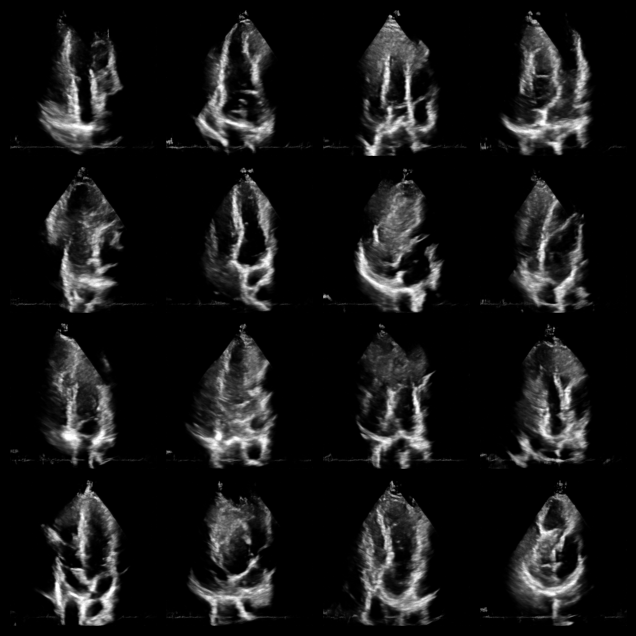

In [7]:
fig, _ = plot_image_grid(prior_samples, vmin=-1, vmax=1)

## Load hazy ultrasound data

Now let's load a real cardiac ultrasound video with haze/noise artifacts. We'll use Nuclear Diffusion to separate the tissue signal from the low-rank haze background. The data is loaded from Hugging Face containing echocardiography videos from the DehazingEcho2025 dataset.

In [8]:
# Load data from HDF5 file
with zea.File("hf://zeahub/DehazingEcho2025/noisy/patient-1-4C.hdf5") as f:
    # Note that this example notebook uses an older dataset version
    # the "image_sc" key has been removed since.
    data_np = f["data"]["image_sc"][:]

# Convert to tensor and normalize
data_np = np.expand_dims(data_np, axis=-1)
data = ops.convert_to_tensor(data_np, dtype="float32")
data = translate(data, (0, 255), (-1, 1))

zea: WARNING This ``zea.File`` '/root/.cache/zea/huggingface/datasets/datasets--zeahub--DehazingEcho2025/snapshots/8b439cd542310f48d50be3769e23a4d2c1b582e5/noisy/patient-1-4C.hdf5' was created with a legacy version of zea (<0.1.0), while you are using zea v0.1.0. It may behave in unexpected ways. Install an earlier version of zea<0.1.0 for full compatibility or re-save the file with zea v0.1.0 or later (e.g. via File.create).


## Nuclear diffusion posterior sampling

The following functions implement the Nuclear Diffusion algorithm for video dehazing. The key steps are:

1. **Window-based processing**: Long videos are split into overlapping windows to manage memory.
2. **Joint sampling**: For each window, we jointly sample tissue $\mathbf{X}$ and haze $\mathbf{L}$ components.
3. **Iterative refinement**: Alternates between:
   - Reverse diffusion on tissue using the learned prior $p_\theta(\mathbf{X})$
   - Gradient updates enforcing measurement consistency and low-rank structure on haze
4. **Averaging**: Overlapping window predictions are averaged to produce smooth results.

## Apply nuclear diffusion dehazing

Now we'll apply the Nuclear Diffusion method to the loaded hazy video. The hyperparameters control:

- **omega** ($\omega$): Weight for the measurement consistency term (L2 reconstruction error)
- **gamma** ($\gamma$): Weight for the nuclear norm penalty (low-rank enforcement)
- **rank_weight_factor**: Optional enhanced weighting for larger singular values
- **initial_step**: Starting step for progressive blending of haze component
- **window_size**: Number of frames to process together (manages memory for long videos)

The dehazing will process the video in windows and may take several minutes depending on hardware.

In [9]:
pred_tissue_images, pred_haze_images = dehaze_nuclear_diffusion(
    data,
    diffusion_model=model,
    n_steps=diffusion_steps,
    window_size=window_size,
    hard_project=hard_project,
    seed=seed_gen,
    omega=omega,
    gamma=gamma,
    haze_level=haze_level,
    rank_weight_factor=rank_weight_factor,
    initial_step=initial_step,
)

zea: [Nuclear Diffusion] Processing 60 frames.
zea: [Nuclear Diffusion] Split into 9 windows with sizes: [7, 7, 7, 7, 7, 7, 7, 7, 4]
9/9 ━━━━━━━━━━━━━━━━━━━━ 125s 13s/window


## Visualize results

The animation below shows three panels for each frame:
1. **Hazy input**: The original measurement with haze artifacts
2. **Dehazed tissue**: The recovered tissue signal with enhanced contrast
3. **Haze estimate**: The low-rank background component removed by Nuclear Diffusion

Notice how the dehazed images have improved contrast between myocardium and left ventricle by reducing haze artifacts while preserving fine anatomical details and tissue texture.

In [10]:
# Convert data to numpy for visualization
data_np = ops.convert_to_numpy(data)

animation_frames = []
for t in range(len(data_np)):
    # Stack the three panels: input, dehazed, haze
    panels = np.stack([data_np[t], pred_tissue_images[t], pred_haze_images[t]])[..., 0]
    fig, _ = plot_image_grid(
        panels,
        ncols=3,
        titles=["Hazy Input", "Dehazed Tissue", "Haze Estimate"],
        vmin=-1,
        vmax=1,
        figsize=(9, 3),
    )
    for ax in fig.axes:
        ax.title.set_fontsize(10)
    arr = zea.io_lib.matplotlib_figure_to_numpy(fig)
    plt.close(fig)
    animation_frames.append(arr)

save_path = "dehazing_results.gif"
zea.io_lib.save_to_gif(animation_frames, save_path, fps=15, shared_color_palette=False)
log.info(f"Animation saved to {save_path}")

zea: Successfully saved GIF to -> dehazing_results.gif
zea: Animation saved to dehazing_results.gif


'Animation saved to dehazing_results.gif'


![Dehazing Results](./dehazing_results.gif)

## Summary

This notebook demonstrated **Nuclear Diffusion**, a hybrid method that combines:
- **Diffusion priors** for modeling complex signal structure
- **Nuclear norm penalties** for low-rank temporal background modeling

The method successfully separates tissue dynamics from structured haze in cardiac ultrasound videos, achieving improved contrast while preserving anatomical details.

**Key advantages over traditional RPCA:**
- Replaces restrictive sparsity assumptions with expressive learned priors
- Better captures rich variability in real-world video signals
- Improved contrast enhancement (gCNR) and signal preservation (KS statistic)

**Citation:**
```bibtex
@inproceedings{stevens2026nuclear,
  title={Nuclear Diffusion Models for Low-Rank Background Suppression in Videos},
  author={Stevens, Tristan S. W. and Nolan, Oisín and Robert, Jean-Luc and van Sloun, Ruud J. G.},
  booktitle={IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP)},
  year={2026}
}
```

For more information, see the [paper on arXiv](https://arxiv.org/abs/2509.20886) and the [model on Hugging Face](https://huggingface.co/tristan-deep/semantic-diffusion-echo-dehazing).
